Image size: 1600x900


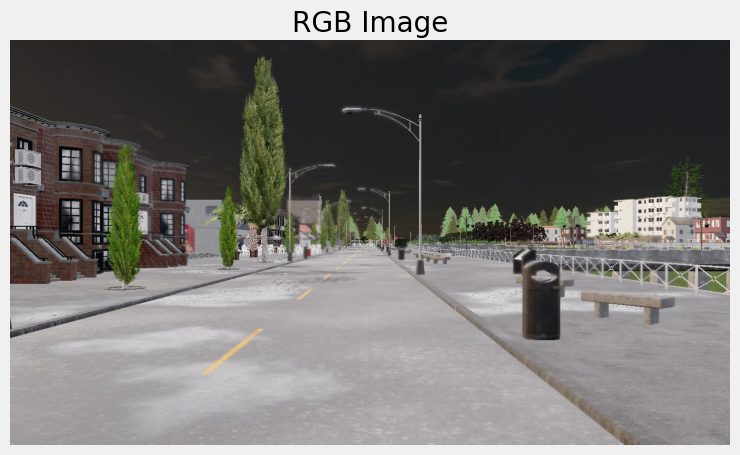

In [10]:
import os
import cv2
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set plotting style
plt.style.use('fivethirtyeight')
%matplotlib inline


RGB_PATH = 'sample_rgb.jpg'  # Path to the RGB image
rgb = cv2.imread(RGB_PATH)     

h, w = rgb.shape[:2]
print(f"Image size: {w}x{h}")   


# plot the image
plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB))
plt.title('RGB Image')
plt.axis('off')
plt.show()

ROI polygon points (x, y):
[[ 217  898]
 [ 780  457]
 [ 825  457]
 [1465  897]]


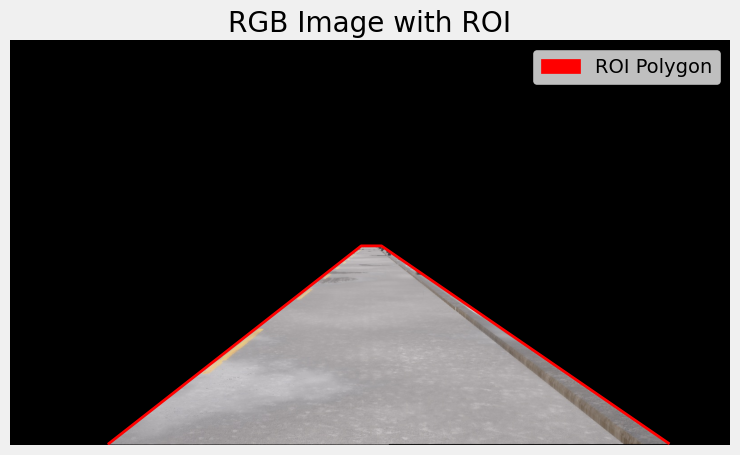

In [13]:
def load_roi_polygon(path):
    """Load polygon from roi.yaml → np.array (N,2) int32, or None."""
    if not os.path.exists(path):
        print("roi.yaml not found — full image used as ROI")
        return None
    with open(path) as f:
        data = yaml.full_load(f)
    raw = data.get("roi", {}).get("polygon", None)
    if raw is None:
        return None
    return np.array([list(p) for p in raw], dtype=np.int32)


ROI_YAML = 'roi.yaml'  # Path to the ROI YAML file
roi_polygon = load_roi_polygon(ROI_YAML)
print("ROI polygon points (x, y):")
print(roi_polygon)


# Apply the ROI mask to the image
if roi_polygon is not None:
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [roi_polygon], 255)
    masked_rgb = cv2.bitwise_and(rgb, rgb, mask=mask)
else:    masked_rgb = rgb.copy()    

# Plot the masked image with ROI polygon
plt.figure(figsize=(14, 5))
plt.imshow(cv2.cvtColor(masked_rgb, cv2.COLOR_BGR2RGB))
if roi_polygon is not None:
    plt.plot(roi_polygon[:, 0], roi_polygon[:, 1], 'r-', linewidth=2, label='ROI Polygon')
    red_patch = mpatches.Patch(color='red', label='ROI Polygon')
    plt.legend(handles=[red_patch])
plt.title('RGB Image with ROI')
plt.axis('off')
plt.show()
